In [94]:
from sklearn.datasets import load_files
import os
import matplotlib.pyplot as plt

In [95]:
PATH_TO_DATA = '../data/aclImdb'

In [96]:
!du -hs $PATH_TO_DATA/train
!du -hs $PATH_TO_DATA/test

102M	../data/aclImdb/train
122M	../data/aclImdb/test


In [97]:
%%time
train_review = load_files(os.path.join(PATH_TO_DATA, 'train'))
test_review = load_files(os.path.join(PATH_TO_DATA, 'test'))

CPU times: user 508 ms, sys: 217 ms, total: 724 ms
Wall time: 723 ms


In [98]:
type(train_review)

sklearn.utils._bunch.Bunch

In [99]:
len(test_review.data)

25000

In [100]:
train_review.data[0]

b"Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty."

In [101]:
train_review.target[0]  # 1 - good

np.int64(1)

In [102]:
train_review.data[1]

b'Words can\'t describe how bad this movie is. I can\'t explain it by writing only. You have too see it for yourself to get at grip of how horrible a movie really can be. Not that I recommend you to do that. There are so many clich\xc3\xa9s, mistakes (and all other negative things you can imagine) here that will just make you cry. To start with the technical first, there are a LOT of mistakes regarding the airplane. I won\'t list them here, but just mention the coloring of the plane. They didn\'t even manage to show an airliner in the colors of a fictional airline, but instead used a 747 painted in the original Boeing livery. Very bad. The plot is stupid and has been done many times before, only much, much better. There are so many ridiculous moments here that i lost count of it really early. Also, I was on the bad guys\' side all the time in the movie, because the good guys were so stupid. "Executive Decision" should without a doubt be you\'re choice over this one, even the "Turbulenc

In [103]:
train_review.target[1]  # 0 - bad

np.int64(0)

# Bag Of Words

In [104]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

In [105]:
a = np.zeros([5, 5]).astype(int)
a[0,3] = 1
a[4,4] = 6
a[2,2] = 5
a[3,1] = 4
a[1,1] = 7
a[3,2] = 2

In [106]:
a

array([[0, 0, 0, 1, 0],
       [0, 7, 0, 0, 0],
       [0, 0, 5, 0, 0],
       [0, 4, 2, 0, 0],
       [0, 0, 0, 0, 6]])

In [107]:
pd.DataFrame(a, columns=['apple', 'banana', 'sadness', 'lucky', 'girl'])

,apple,banana,sadness,lucky,girl
0,0,0,0,1,0
1,0,7,0,0,0
2,0,0,5,0,0
3,0,4,2,0,0
4,0,0,0,0,6


In [108]:
b = csr_matrix(a)
b

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (5, 5)>

In [109]:
b.todense()  # возвращение в формат матрицы a

matrix([[0, 0, 0, 1, 0],
        [0, 7, 0, 0, 0],
        [0, 0, 5, 0, 0],
        [0, 4, 2, 0, 0],
        [0, 0, 0, 0, 6]])

In [110]:
b.nonzero()

(array([0, 1, 2, 3, 3, 4], dtype=int32),
 array([3, 1, 2, 1, 2, 4], dtype=int32))

In [111]:
b.data

array([1, 7, 5, 4, 2, 6])

In [112]:
from sklearn.feature_extraction.text import CountVectorizer

In [113]:
# Подсчет слов
cv = CountVectorizer(ngram_range=(1,2))
X_train_sparse = cv.fit_transform(train_review.data)

In [114]:
cv.vocabulary_

{'zero': 1512013,
 'day': 338102,
 'leads': 750958,
 'you': 1505684,
 'to': 1344321,
 'think': 1323575,
 'even': 433838,
 're': 1060857,
 'why': 1468368,
 'two': 1379425,
 'boys': 195966,
 'young': 1507527,
 'men': 826158,
 'would': 1495529,
 'do': 377248,
 'what': 1452309,
 'they': 1320079,
 'did': 360938,
 'commit': 289039,
 'mutual': 871902,
 'suicide': 1248069,
 'via': 1414989,
 'slaughtering': 1181047,
 'their': 1309193,
 'classmates': 273518,
 'it': 697185,
 'captures': 237559,
 'must': 871029,
 'be': 146209,
 'beyond': 172628,
 'bizarre': 178463,
 'mode': 843072,
 'of': 914447,
 'being': 162100,
 'for': 499356,
 'humans': 638861,
 'who': 1463784,
 'have': 587360,
 'decided': 343363,
 'withdraw': 1483967,
 'from': 517404,
 'common': 289312,
 'civility': 271010,
 'in': 653396,
 'order': 954262,
 'define': 345812,
 'own': 969039,
 'world': 1492678,
 'coupled': 313554,
 'destruction': 355951,
 'br': 196310,
 'is': 686540,
 'not': 900379,
 'perfect': 988774,
 'movie': 858752,
 'but':

In [115]:
len(cv.vocabulary_)

1513832

In [116]:
X_test_sparse = cv.transform(test_review.data)

In [117]:
X_train_sparse.shape, X_test_sparse.shape

((25000, 1513832), (25000, 1513832))

In [118]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score

In [119]:
y_train, y_test = train_review.target, test_review.target

In [120]:
np.bincount(y_train), np.bincount(y_test)

(array([12500, 12500]), array([12500, 12500]))

In [121]:
logit = LogisticRegression(random_state=15, solver='lbfgs')
sgd_logit = SGDClassifier(random_state=15, n_jobs=-1, max_iter=40)

In [122]:
%%time
logit.fit(X_train_sparse, y_train)

CPU times: user 28.2 s, sys: 1e+03 ms, total: 29.2 s
Wall time: 19.3 s


/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",15
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [123]:
%%time
sgd_logit.fit(X_train_sparse, y_train)

CPU times: user 1.23 s, sys: 12.8 ms, total: 1.25 s
Wall time: 1.24 s


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",40
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [124]:
round(logit.score(X_train_sparse, y_train), 5), round(sgd_logit.score(X_train_sparse, y_train), 5)

(0.99996, 0.9998)

In [125]:
round(logit.score(X_test_sparse, y_test), 5), round(sgd_logit.score(X_test_sparse, y_test), 5)

(0.89632, 0.88928)

In [126]:
def visualize_coefficients(classifier, feature_names, n_top_features=25):
    coef = classifier.coef_.ravel()
    positive_coefficients = np.argsort(coef)[-n_top_features:]
    negative_coefficients = np.argsort(coef)[:n_top_features]
    interesting_coefficients = np.hstack([negative_coefficients, positive_coefficients])

    plt.figure(figsize=(15, 5))
    colors = ["red" if c < 0 else "blue" for c in coef[interesting_coefficients]]
    plt.bar(np.arange(2 * n_top_features), coef[interesting_coefficients], color=colors)
    feature_names = np.array(feature_names)
    plt.xticks(
        np.arange(1, 1 + 2 * n_top_features),
        feature_names[interesting_coefficients],
        rotation=60,
        ha="right",
    );

In [127]:
from matplotlib.pyplot import plot, legend

def plot_grid_scores(grid, param_name):
    param_key = f"param_{param_name}"
    param_values = [x for x in grid.cv_results_[param_key]]

    plot(
        param_values,
        grid.cv_results_["mean_train_score"],
        color="green",
        label="train",
    )
    plot(
        param_values,
        grid.cv_results_["mean_test_score"],
        color="red",
        label="test",
    )
    legend()

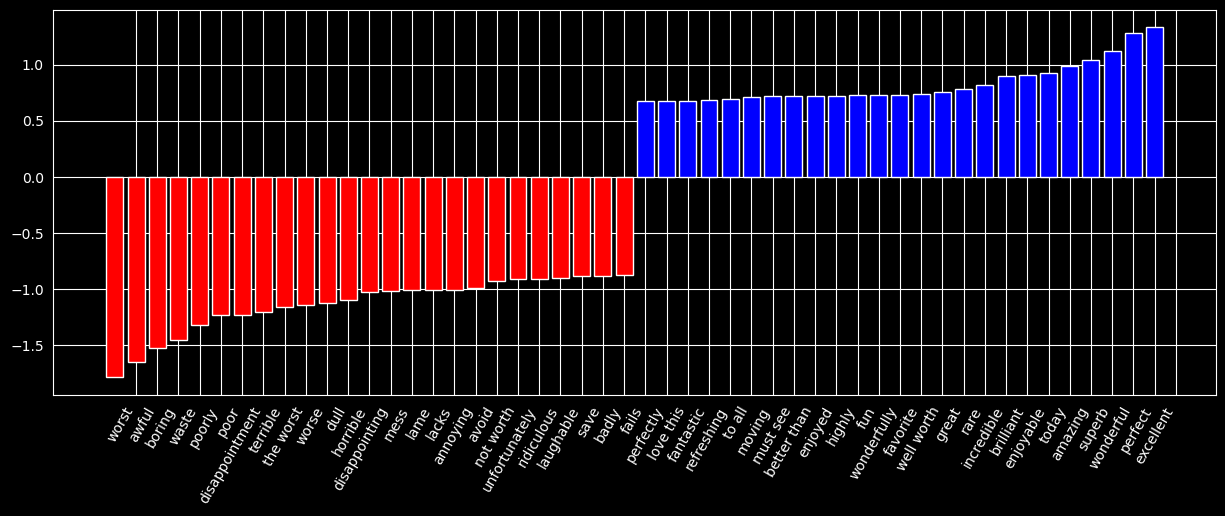

In [128]:
visualize_coefficients(logit, cv.get_feature_names_out())

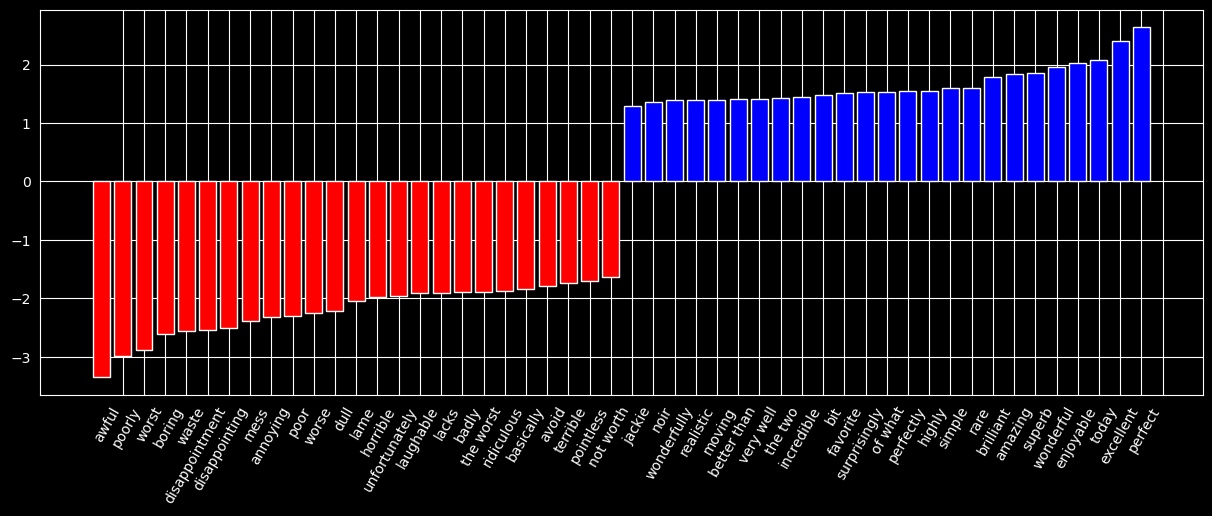

In [129]:
visualize_coefficients(sgd_logit, cv.get_feature_names_out())

In [130]:
%%time
from sklearn.pipeline import make_pipeline

text_pipe_logit = make_pipeline(CountVectorizer(), LogisticRegression(random_state=7))

text_pipe_logit.fit(train_review.data, y_train)
print(text_pipe_logit.score(test_review.data, y_test))

/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.86364
CPU times: user 9.56 s, sys: 569 ms, total: 10.1 s
Wall time: 9.56 s


In [131]:
%%time
from sklearn.model_selection import GridSearchCV

param_grid_logit = {"logisticregression__C": np.logspace(-5, 0, 6), "logisticregression__max_iter": [1000]}
grid_logit = GridSearchCV(text_pipe_logit, param_grid_logit, cv=3, return_train_score=True)

grid_logit.fit(train_review.data, y_train)

CPU times: user 2min 48s, sys: 13.1 s, total: 3min 1s
Wall time: 2min 51s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=7))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__C': array([1.e-05...e-01, 1.e+00]), 'logisticregression__max_iter': [1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [132]:
grid_logit.best_params_, grid_logit.best_score_

({'logisticregression__C': np.float64(0.1),
  'logisticregression__max_iter': 1000},
 np.float64(0.8850799628337426))

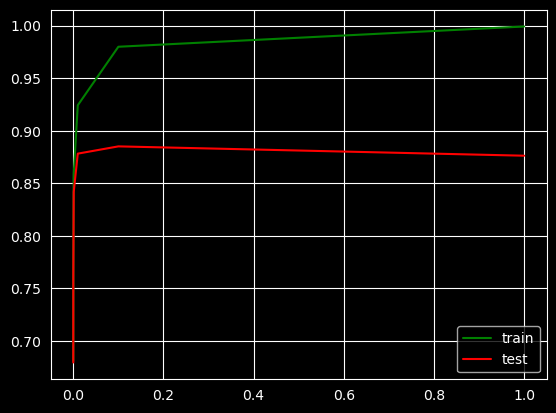

In [133]:
plot_grid_scores(grid_logit, "logisticregression__C")

In [134]:
%%time

from sklearn.svm import LinearSVC

text_pipe_svm = make_pipeline(CountVectorizer(), LinearSVC(random_state=7))

text_pipe_svm.fit(train_review.data, y_train)
print(text_pipe_svm.score(test_review.data, y_test))

/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.84572
CPU times: user 10 s, sys: 23.6 ms, total: 10.1 s
Wall time: 10.1 s


In [135]:
%%time
param_grid_svm = {"linearsvc__C": np.logspace(-5, 0, 6)}
grid_svm = GridSearchCV(text_pipe_svm, param_grid_svm, cv=3, n_jobs=-1, return_train_score=True)

grid_svm.fit(train_review.data, y_train);

/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the

CPU times: user 7.14 s, sys: 286 ms, total: 7.42 s
Wall time: 23.4 s


In [136]:
grid_svm.best_params_, grid_svm.best_score_

({'linearsvc__C': np.float64(0.01)}, np.float64(0.8830799500278547))

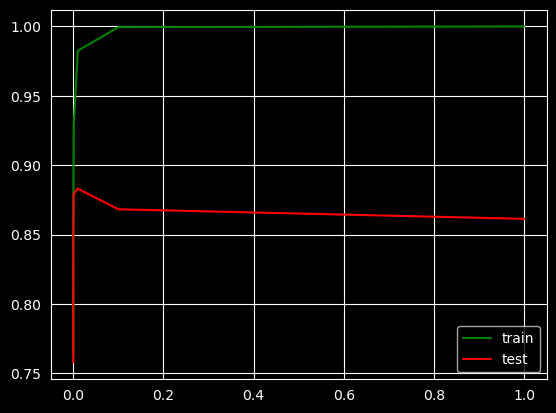

In [137]:
plot_grid_scores(grid_svm, "linearsvc__C")

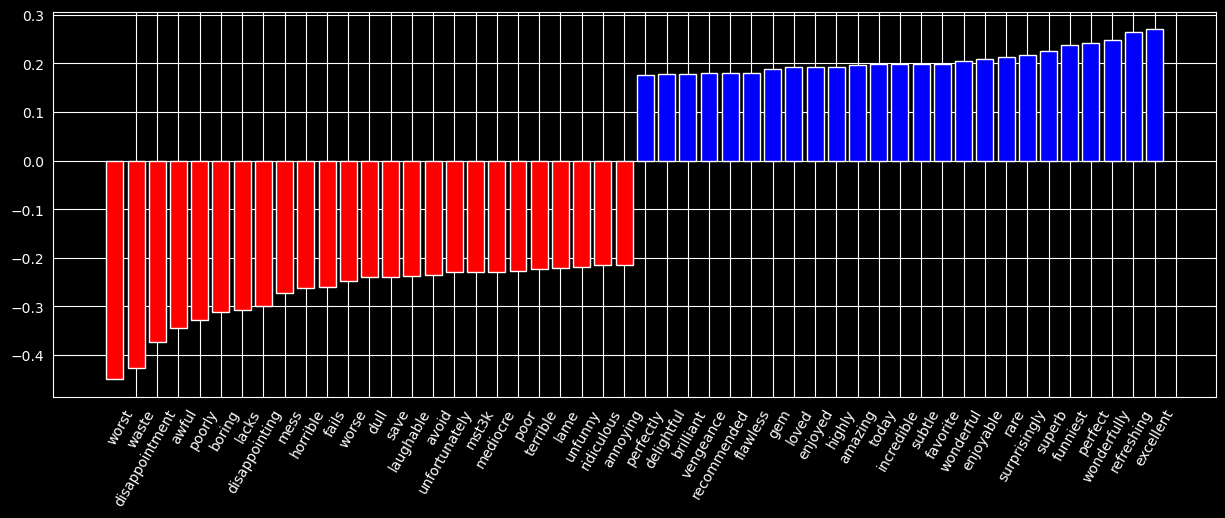

In [138]:
visualize_coefficients(
    grid_svm.best_estimator_.named_steps["linearsvc"],
    grid_svm.best_estimator_.named_steps["countvectorizer"].get_feature_names_out()
)

In [139]:
grid_logit.score(test_review.data, y_test), grid_svm.score(test_review.data, y_test)

(0.87908, 0.87588)

/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


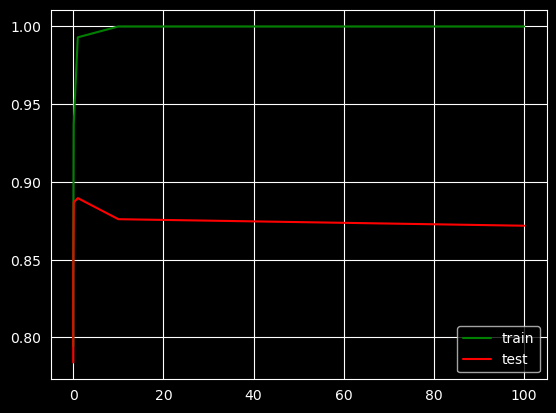

In [140]:
# TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pipe = make_pipeline(TfidfVectorizer(), LinearSVC())

param_grid = {"linearsvc__C": np.logspace(-3, 2, 6)}
grid_tfidf = GridSearchCV(tfidf_pipe, param_grid, cv=3, n_jobs=-1, return_train_score=True)
grid_tfidf.fit(train_review.data, y_train)
plot_grid_scores(grid_tfidf, "linearsvc__C")

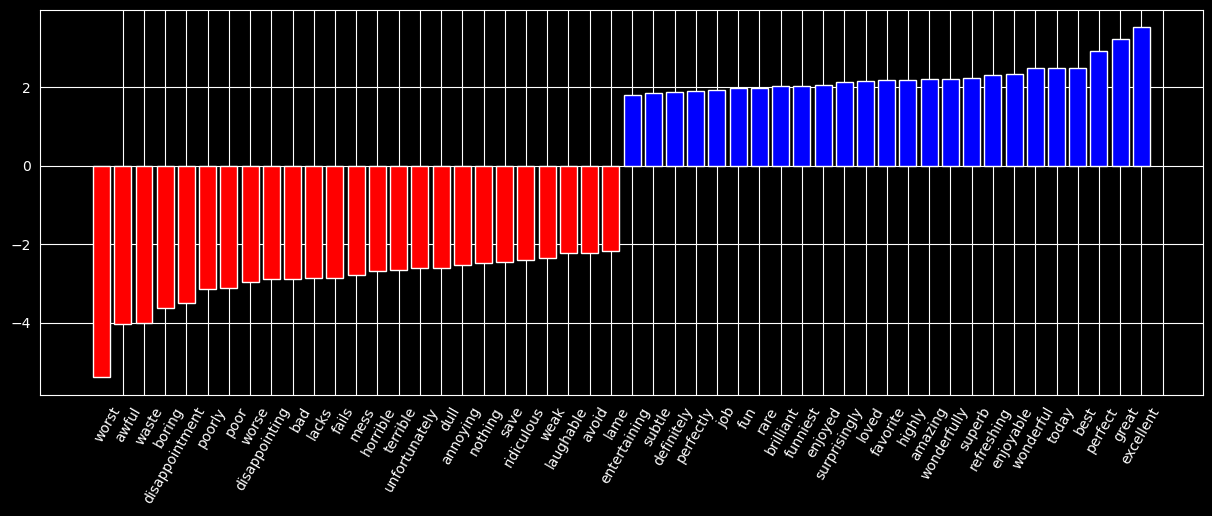

In [141]:
visualize_coefficients(
    grid_tfidf.best_estimator_.named_steps["linearsvc"],
    grid_tfidf.best_estimator_.named_steps["tfidfvectorizer"].get_feature_names_out()
)

In [142]:
grid_tfidf.best_score_, grid_tfidf.best_params_

(np.float64(0.889599966048078), {'linearsvc__C': np.float64(1.0)})

In [144]:
# N-граммы
text_pipe = make_pipeline(CountVectorizer(), LinearSVC())

param_grid = {"linearsvc__C": [0.01, 0.1, 1], "countvectorizer__ngram_range": [(1, 2)]}

grid_bigram = GridSearchCV(text_pipe, param_grid, cv=3, return_train_score=True)

grid_bigram.fit(train_review.data, y_train)

/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...LinearSVC())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'countvectorizer__ngram_range': [(1, ...)], 'linearsvc__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [145]:
grid_bigram.best_score_

np.float64(0.8920801804474388)